In [1]:
import sys
import os

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")
print(f"Does it exist? {os.path.exists(src_path)}")

import numpy as np
import matplotlib.pyplot as plt
from mess.data.gp_regression import generate_gp_regression_data
from mess.problems.gp_regression import GaussianProcessRegression
from mess.algorithms.ess import ess_step
from mess.algorithms.mess import mess_step

Repo root: /Users/guillers/Documents/GitHub/mess
Added to path: /Users/guillers/Documents/GitHub/mess/src
Does it exist? True


In [2]:
# Problem parameters
num_data = 200
D = 5
length_scale = 1.0
noise_variance = 0.09

# Sampler parameters
n_iters = 2000
burn_in = 0

seed = 0


In [3]:
data = generate_gp_regression_data(
    num_data=num_data,
    num_dims=D,
    length_scale=length_scale,
    noise_variance=noise_variance,
    seed=seed,
)

X = data["X"]
y = data["y"]
x0 = data["f_init"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5, 200)
y shape: (200,)


In [4]:
problem = GaussianProcessRegression(
    X=X,
    y=y,
    length_scale=length_scale,
    noise_variance=noise_variance,
)
print("Initial log-likelihood:", problem.log_likelihood(x0))

Initial log-likelihood: -1794.5296365567697


In [5]:
rng_ess = np.random.default_rng(seed)

chain_ess = np.zeros((n_iters, num_data))
intervals_ess = np.zeros(n_iters, dtype=int)    
x = x0.copy()

for t in range(n_iters):
    x, nr_intervals_ess, P1_ess = ess_step(x, problem, rng_ess)
    chain_ess[t] = x
    intervals_ess[t] = nr_intervals_ess


In [24]:
rng_mess = np.random.default_rng(seed)

M = 5
chain_mess = np.zeros((n_iters, num_data))
intervals_mess = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Uniform transition matrix
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M)
    chain_mess[t] = x
    intervals_mess[t] = nr_intervals_mess


In [25]:
rng_mess = np.random.default_rng(seed)

M = 5
chain_mess_ang = np.zeros((n_iters, num_data))
intervals_mess_ang = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Transition matrix with LP, angular distance
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M, 
                                              use_lp=True, distance_metric='angular', 
                                              lam=0.1)
    chain_mess_ang[t] = x
    intervals_mess_ang[t] = nr_intervals_mess

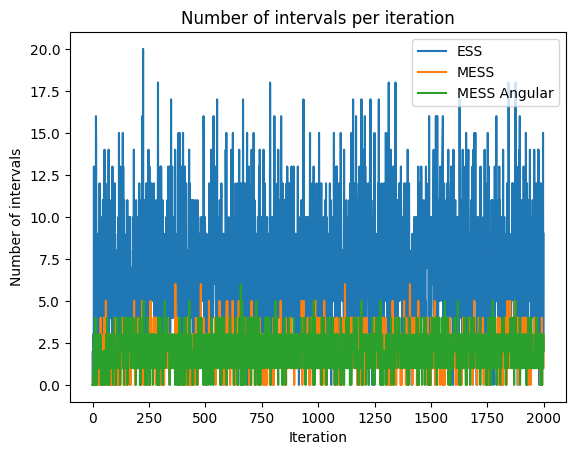

In [26]:
plt.plot(intervals_ess)
plt.plot(intervals_mess)
plt.plot(intervals_mess_ang)
plt.xlabel("Iteration")
plt.ylabel("Number of intervals")
plt.legend(["ESS", "MESS", "MESS Angular"])
plt.title("Number of intervals per iteration")
plt.show()

Text(0.5, 1.0, 'Log-likelihood trace')

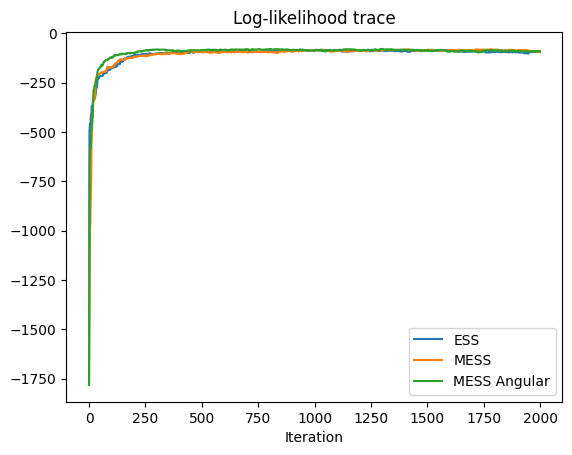

In [27]:
ll_ess = np.array([problem.log_likelihood(x) for x in chain_ess])
ll_mess = np.array([problem.log_likelihood(x) for x in chain_mess])
ll_mess_ang = np.array([problem.log_likelihood(x) for x in chain_mess_ang])

plt.plot(ll_ess[burn_in:], label="ESS")
plt.plot(ll_mess[burn_in:], label="MESS")
plt.plot(ll_mess_ang[burn_in:], label="MESS Angular")
plt.xlabel("Iteration")
plt.legend()
plt.title("Log-likelihood trace")


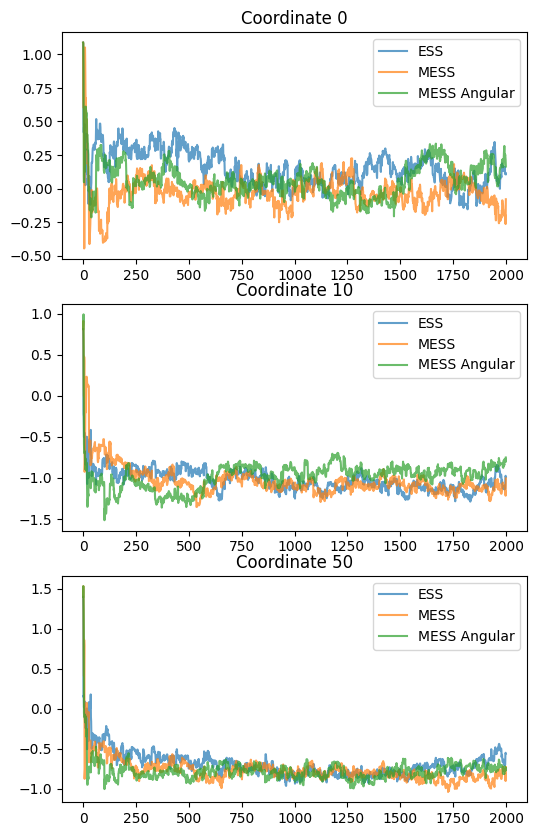

In [28]:
idx = [0, 10, 50]

fig, axes = plt.subplots(len(idx), 1, figsize=(6, 10))
for i, k in enumerate(idx):
    axes[i].plot(chain_ess[burn_in:, k], alpha=0.7, label="ESS")
    axes[i].plot(chain_mess[burn_in:, k], alpha=0.7, label="MESS")
    axes[i].plot(chain_mess_ang[burn_in:, k], alpha=0.7, label="MESS Angular")
    axes[i].set_title(f"Coordinate {k}")
    axes[i].legend()


In [ ]:
# Traceplot for all coordinates and algorithms at the same time
idx = [0, 10, 50]

fig, axes = plt.subplots(len(idx), 1, figsize=(6, 10))
for i, k in enumerate(idx):
    axes[i].plot(chain_ess[burn_in:, k], alpha=0.7, label="ESS")
    axes[i].plot(chain_mess[burn_in:, k], alpha=0.7, label="MESS")
    axes[i].plot(chain_mess_ang[burn_in:, k], alpha=0.7, label="MESS Angular")
    axes[i].set_title(f"Coordinate {k}")
    axes[i].legend()


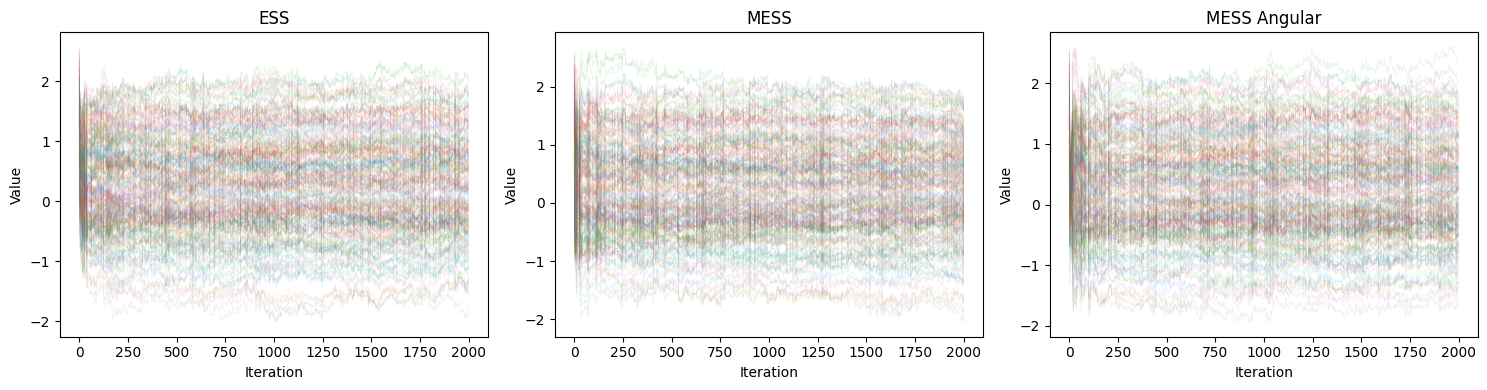

In [32]:
# Traceplot for all coordinates and algorithms at the same time
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

algorithms = [
    ("ESS", chain_ess[burn_in:]),
    ("MESS", chain_mess[burn_in:]),
    ("MESS Angular", chain_mess_ang[burn_in:])
]

for idx, (algo_name, chain) in enumerate(algorithms):
    for k in range(num_data):
        axes[idx].plot(chain[:, k], alpha=0.1, linewidth=0.5)
    axes[idx].set_title(algo_name)
    axes[idx].set_xlabel("Iteration")
    axes[idx].set_ylabel("Value")

plt.tight_layout()
plt.show()

In [30]:
f_true = data["f_true"]

samples_ess = chain_ess[burn_in:]
samples_mess = chain_mess[burn_in:]
samples_mess_ang = chain_mess_ang[burn_in:]

mean_ess = samples_ess.mean(axis=0)
mean_mess = samples_mess.mean(axis=0)
mean_mess_ang = samples_mess_ang.mean(axis=0)

std_ess = samples_ess.std(axis=0)
std_mess = samples_mess.std(axis=0)
std_mess_ang = samples_mess_ang.std(axis=0)


Text(0, 0.5, 'f')

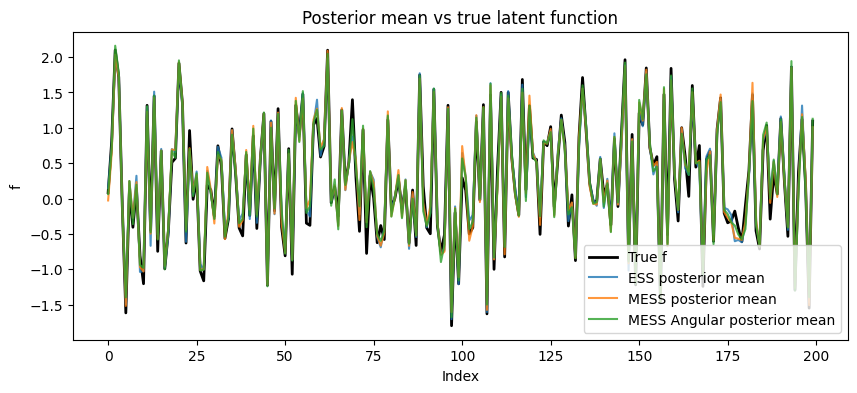

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(f_true, label="True f", color="black", linewidth=2)
plt.plot(mean_ess, label="ESS posterior mean", alpha=0.8)
plt.plot(mean_mess, label="MESS posterior mean", alpha=0.8)
plt.plot(mean_mess_ang, label="MESS Angular posterior mean", alpha=0.8)
plt.legend()
plt.title("Posterior mean vs true latent function")
plt.xlabel("Index")
plt.ylabel("f")


Text(0.5, 1.0, 'Posterior mean error')

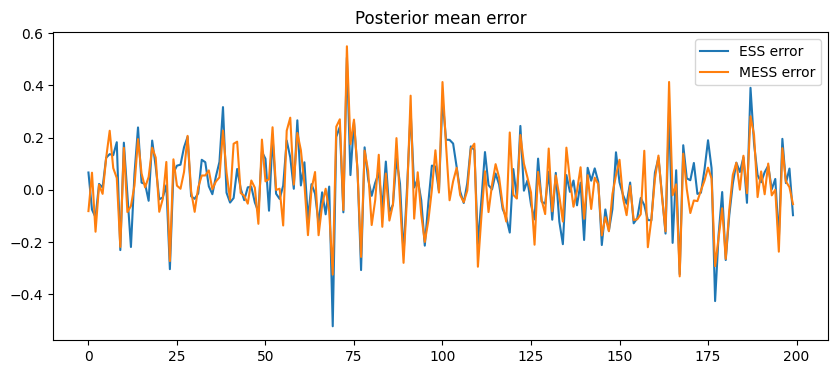

In [19]:
err_ess = mean_ess - f_true
err_mess = mean_mess - f_true

plt.figure(figsize=(10, 4))
plt.plot(err_ess, label="ESS error")
plt.plot(err_mess, label="MESS error")
plt.legend()
plt.title("Posterior mean error")


In [20]:
rmse_ess = np.sqrt(np.mean(err_ess**2))
rmse_mess = np.sqrt(np.mean(err_mess**2))

print("RMSE ESS :", rmse_ess)
print("RMSE MESS:", rmse_mess)


RMSE ESS : 0.1390367002230413
RMSE MESS: 0.1394175954518371


Text(0.5, 1.0, 'Standardized posterior error')

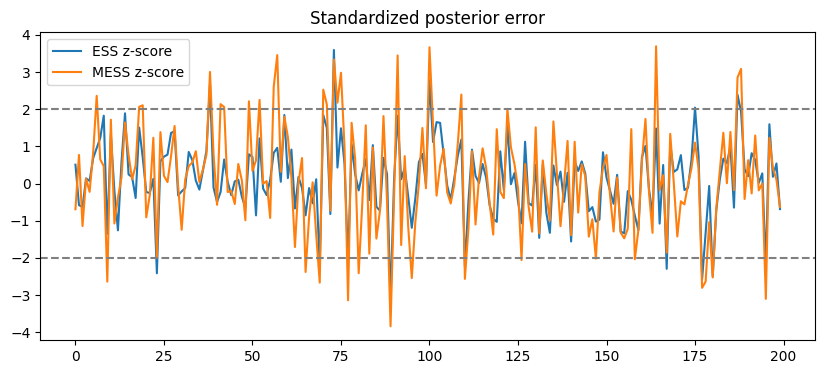

In [21]:
z_ess = (mean_ess - f_true) / std_ess
z_mess = (mean_mess - f_true) / std_mess

plt.figure(figsize=(10, 4))
plt.plot(z_ess, label="ESS z-score")
plt.plot(z_mess, label="MESS z-score")
plt.axhline(2, color="gray", linestyle="--")
plt.axhline(-2, color="gray", linestyle="--")
plt.legend()
plt.title("Standardized posterior error")


In [22]:
lower_ess = np.percentile(samples_ess, 2.5, axis=0)
upper_ess = np.percentile(samples_ess, 97.5, axis=0)

coverage_ess = np.mean(
    (f_true >= lower_ess) & (f_true <= upper_ess)
)

print("ESS 95% coverage:", coverage_ess)

# replicate for MESS
lower_mess = np.percentile(samples_mess, 2.5, axis=0)
upper_mess = np.percentile(samples_mess, 97.5, axis=0)
coverage_mess = np.mean(
    (f_true >= lower_mess) & (f_true <= upper_mess)
)   
print("MESS 95% coverage:", coverage_mess)

ESS 95% coverage: 0.93
MESS 95% coverage: 0.805


Text(0.5, 1.0, 'Posterior mean vs observations')

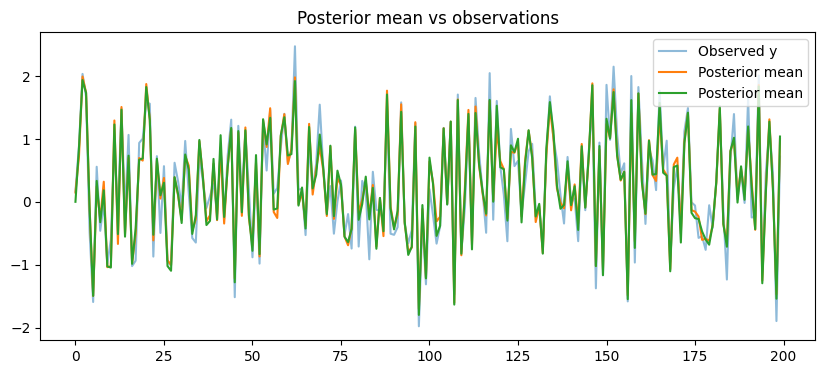

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(y, label="Observed y", alpha=0.5)
plt.plot(mean_ess, label="Posterior mean")
plt.plot(mean_mess, label="Posterior mean")
plt.legend()
plt.title("Posterior mean vs observations")
